In [2]:
import pandas as pd 
import numpy as np 
import bnlearn as bn
from bnlearn import parameter_learning, plot
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import os

In [3]:
os.chdir('../')

### Import data

In [ ]:
# import dataa
dir_params =os.path.join(os.getcwd(),'PhenoData\Dataset_order_202301\SPSS\SPSSFiles')
filename = 'RegularQuestionaire_PlusCOVIDActions_17June.csv'
file_path = os.path.join(dir_params,filename)
data = pd.read_csv(file_path)
df = data [['gender', 'age_cat', 'education_level', 'unemployed','partner','depressed', 'children_presence', 'housing_financial_trouble', 'selfrated_health', 'critical_job']].copy()



### Built-in learning structure algorithms

In [7]:
#save model
def saveto(model, method, out_folder):
    # save model
    with open(f"{out_folder}/BN_{method}.pkl", 'wb') as f:
        pickle.dump(file=f, obj=model)
        
# Fiting data in built-in structure
def fit_bn(df, methodlist, classnode, out_folder):
    dfhot, dfnum = bn.df2onehot(df)

    for method in methodlist:
        model = bn.structure_learning.fit(dfnum, methodtype=method, class_node=classnode)
        # save model
        saveto(model, method, out_folder)

#print DAGs outcome
def print_dag(model_folder):
    dir_params =os.path.join(os.getcwd(),model_folder)
    filenames = [i[:-4] for i in os.listdir(dir_params)]

    models = {}

    file_paths = [os.path.join(dir_params,x) for x in os.listdir(dir_params)]

    for i in range(len(file_paths)):
        with open(f'{file_paths[i]}', 'rb') as f:
            models[filenames[i]] = pickle.load(f)
            
    for model in list(models.keys()): 
        print(f'DAG - {model}')
        bn.plot(models[model])
        


Experiment 1 - sample data titanic

In [4]:
methodlist = ['hc', 'cs', 'tan',] 
classnode='depressed'
fit_bn(df, classnode, 'bn_models')



[df2onehot] >Auto detecting dtypes.


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 254.83it/s]


[df2onehot] >Set dtypes in dataframe..


[df2onehot]: 100%|██████████| 12/12 [00:00<00:00, 274.83it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Warning: Structure scoring could not be computed. Method [cs] not supported.
[bnlearn] >Filter variables (nodes) on black_list..
[bnlearn] >Number of features after white/black listing: 7
[bnlearn] >Computing best DAG using [tan]


Building tree:   0%|          | 0/21.0 [00:00<?, ?it/s]

Building tree:   0%|          | 0/21.0 [00:00<?, ?it/s]

[bnlearn] >Compute structure scores for model comparison (higher is better).


### Manual setup BN

In [ ]:
# Building customized tructure


structure = {
    'gender': ['selfrated_health', 'critical_job', 'partner'],
    'age_cat': ['critical_job', 'education_level','selfrated_health','children_presence', 'partner'],
    'unemployed':['partner', 'housing_financial_trouble'],#'children'
    'education_level': ['unemployed', 'critical_job', 'depressed', 'selfrated_health', 'children_presence', 'housing_financial_trouble', 'partner'],
    'partner': ['depressed', 'children_presence'],#'selfrated_health'
    'children_presence':['housing_financial_trouble'],
    'selfrated_health':['depressed'], #, 'unemployed'
    'housing_financial_trouble':['selfrated_health', ] #'partner'
}
manual_edges = [(k, vn) for k, v in structure.items() for vn in v]

# Forming DAG
manual_dag = bn.make_DAG(manual_edges)

# Fit data
model_manual = bn.parameter_learning.fit(manual_dag, df)
saveto(model_manual, 'manual', 'bn_models')


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


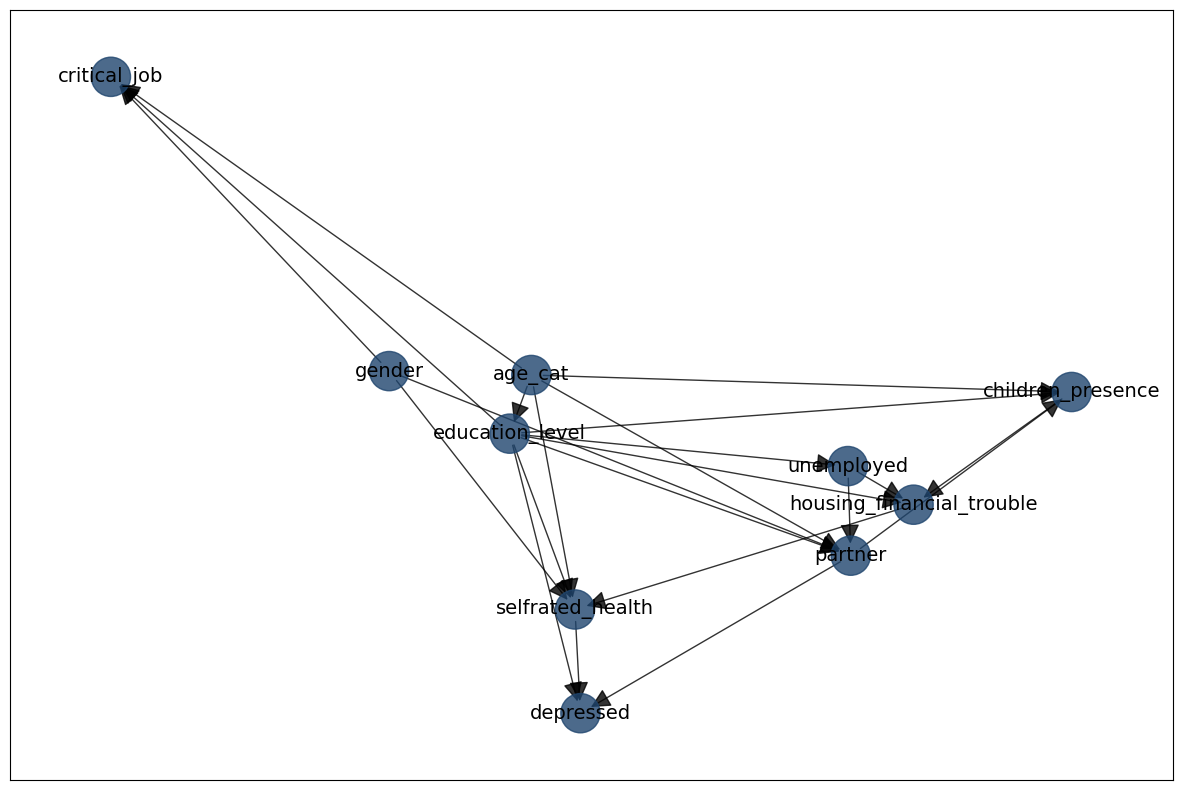

In [11]:
print_dag('bn_models')

